# LAB 1 - Linear Regression
# Antonin Victorion - BIA
## Data presentation & exploration


In [1]:
import pandas as pd
data = pd.read_csv("HousingData.csv")
print(data.head())

      CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD  TAX  PTRATIO  \
0  0.00632  18.0   2.31   0.0  0.538  6.575  65.2  4.0900    1  296     15.3   
1  0.02731   0.0   7.07   0.0  0.469  6.421  78.9  4.9671    2  242     17.8   
2  0.02729   0.0   7.07   0.0  0.469  7.185  61.1  4.9671    2  242     17.8   
3  0.03237   0.0   2.18   0.0  0.458  6.998  45.8  6.0622    3  222     18.7   
4  0.06905   0.0   2.18   0.0  0.458  7.147  54.2  6.0622    3  222     18.7   

        B  LSTAT  MEDV  
0  396.90   4.98  24.0  
1  396.90   9.14  21.6  
2  392.83   4.03  34.7  
3  394.63   2.94  33.4  
4  396.90    NaN  36.2  


In [55]:
from ydata_profiling import ProfileReport

profile = ProfileReport(data, title='Boston Housing Data Report')
profile.to_file('boston_housing_report.html')

Export report to file: 100%|██████████| 1/1 [00:00<00:00, 21.72it/s]


## Variable Selection Activity
### Exploring Correlations

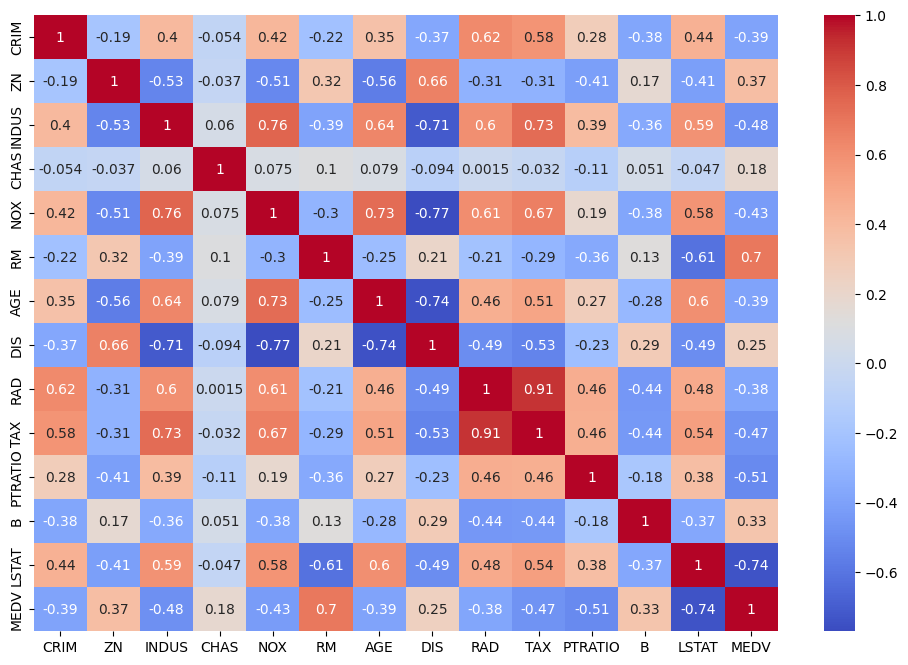

MEDV    1.000000
RM      0.695360
ZN      0.373136
B       0.333461
Name: MEDV, dtype: float64
LSTAT     -0.735822
RM         0.695360
PTRATIO   -0.507787
INDUS     -0.481772
TAX       -0.468536
Name: MEDV, dtype: float64


In [12]:
%matplotlib inline

import seaborn as sns
import matplotlib.pyplot as plt

#Generate the correlation matrix
corr_matrix = data.corr()

#Display the correlation matrix
plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, annot = True, cmap = 'coolwarm')

plt.show()

#Identify the top 3 correlated features with MEDV

print(corr_matrix['MEDV'].sort_values(ascending=False).head(4))

medv_corr = corr_matrix['MEDV'].drop('MEDV')

top_features_abs = medv_corr.abs().sort_values(ascending=False).head(5)

top_features = medv_corr.loc[top_features_abs.index]
print(top_features)




##### Wich features are most strongly correlated with MEDV?
 LSTAT is the strongest negative correlation (-0.74); RM is the strongest positive correlation (+0.70)

##### Do you think these features will be good predictors? Why or why not?

Their high absolute correlation (> 0.5) indicates a strong linear relationship with the target variable, so they are important predictors.
However, linear correlation alone doesn't account for non-linear relationships between features, which means those features won't capture all the results on their own.



## Linear Regression on Boston Housing Dataset

### Simple Linear Regression

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Select the feature and target

X = data[['RM']]
y = data['MEDV']

# Split the data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create the model and train it

model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions

y_pred = model.predict(X_test)

# Evaluate the model

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Mean Squared Error: {mse}')
print(f'R-Squared: {r2}')


Mean Squared Error: 46.144775347317264
R-Squared: 0.3707569232254778


##### Discuss the chosen variable (RM) for prediction

The average number of rooms per dwelling (RM) is a natural predictor because larger homes generally command higher market prices.

We can see from those results that we need additional factors for building a more accurate model because a lot of the house prices' variance is unexplained.


### Multiple Linear Regression with OLS

In [16]:
# Select features and target

X = data[['NOX', 'RM', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B']]
y = data['MEDV']

# Split the data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create the model and train it

model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Mean Squared Error: {mse}')
print(f'R-Squared: {r2}')

Mean Squared Error: 32.3014360607114
R-Squared: 0.5595285737530584


##### Discuss the result

Adding variables increases R² and reduces the MSE
Multiple linear Regression captures multi-dimensional drivers of housing value, significantly outperforming the single variable model.

### Multiple Linear Regression with Gradient Descent

#### Prepare your data

In [20]:
# MLR with Gradient Descent

from sklearn.preprocessing import StandardScaler
import numpy as np

# Features and target

X = data[['NOX', 'RM', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B']]
y = data ['MEDV']

# Scale features for faster convergence
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#Add bias column for B0 intercept)
m, n = X_scaled.shape
X_b = np.c_[np.ones((m,1)), X_scaled]



#### Initialize parameters

In [21]:
# Initialize coefficients (B)

beta = np.zeros(n+1) # B0, B1, ...., Bn

#### Gradient Descent loop

In [48]:
learning_rate = 0.01
n_iterations = 1000

for i in range(n_iterations):
    gradients = -2/m * X_b.T.dot(y - X_b.dot(beta))
    beta = beta - learning_rate * gradients

#### Results & Comparison

In [49]:
print("Estimated coefficients (B):")
print(beta)

# Predictions

y_pred = X_b.dot(beta)

# Evaluation

from sklearn.metrics import mean_squared_error, r2_score
print("MSE:", mean_squared_error(y, y_pred))
print("R²:",r2_score(y, y_pred))


Estimated coefficients (B):
[22.53280632 -2.86236827  4.62489276 -2.01650565  1.91339706 -1.98211045
 -2.66374051  1.47364164]
MSE: 29.495005878869442
R²: 0.6506140612216985


##### Compare these values ($\beta_0, \dots, \beta_n$) to LinearRegression().fit(X, y) coefficients.

B0 is the intercept; it represents the baseline average house price when all scaled features are at their mean.

B1, ..., Bn are the slopes. the features are standardized, the magnitude of B directly reflects its relative feature importance.

The normalized coefficients obtained from Gradient Descent match the standardized coefficients from Scikit-Learn's OLS solver

## BONUS

### Handling Missing Values

In [51]:
missing_vals = data.isna().sum()
print("Missing values per column :")
print(missing_vals[missing_vals > 0])

Missing values per column :
CRIM     20
ZN       20
INDUS    20
CHAS     20
AGE      20
LSTAT    20
dtype: int64


#### Srategy 1 --> Drop rows with NaN

In [57]:
data_dropped = data.dropna()

X_drop = data_dropped.drop(columns=['MEDV'])
y_drop = data_dropped['MEDV']

X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(X_drop, y_drop, test_size = 0.2, random_state=42)

model_drop = LinearRegression()
model_drop.fit(X_train_d, y_train_d)
y_pred_drop = model_drop.predict(X_test_d)

print(f"Strategy 1 (Drop rows):")
print(f"Remaining samples : {len(data_dropped)} / {len(data)}")
print(f"MSE               : {mean_squared_error(y_test_d, y_pred_drop):.4f}")
print(f"R² score          : {r2_score(y_test_d, y_pred_drop):.4f}")

                           

Strategy 1 (Drop rows):
Remaining samples : 394 / 506
MSE               : 31.4540
R² score          : 0.6271


#### Strategy 2 --> Median Imputation

In [56]:
data_imputed =data.fillna(data.median())

X_imp = data_imputed.drop(columns=['MEDV'])
y_imp = data_imputed['MEDV']

X_train_i, X_test_i, y_train_i, y_test_i = train_test_split(X_imp, y_imp, test_size=0.2, random_state=42)

model_imp = LinearRegression()
model_imp.fit(X_train_i, y_train_i)
y_pred_imp = model_imp.predict(X_test_i)

print(f"Strategy 2 (Median Imputation):")
print(f"Remaining samples : {len(data_imputed)} / {len(data)}")
print(f"MSE               : {mean_squared_error(y_test_i, y_pred_imp):.4f}")
print(f"R² score          : {r2_score(y_test_i, y_pred_imp):.4f}")



Strategy 2 (Median Imputation):
Remaining samples : 506 / 506
MSE               : 24.9994
R² score          : 0.6591


##### Handling Missing Values
There are 20 missing values each in CRIM, ZN, INDUS, CHAS, AGE, and LSTAT.

- Drop Rows reduce sample size from 506 to 394 (more than 20% of data loss)
- Median Imputation keeps all the samples without distorting feature distributions.

Median imputation is preferable because we can keep our data for training (we don't have data loss), so it doesn't affect the data distribution and statistical aspects.

### Collinearity Between Variables